In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')


Loading Dataset 

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sharmajicoder/amazon-e-commerce/amazon_ecommerce_1M.csv')

print(df.shape)
df.head()

(1000000, 20)


,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  object 
 1   product_id          1000000 non-null  object 
 2   category            1000000 non-null  object 
 3   subcategory         1000000 non-null  object 
 4   brand               1000000 non-null  object 
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  object 
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  object 
 14  shipping_time_days  1000000 non-null  int64  
 15  location        

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Drop rows with critical missing values
df.dropna(subset=[
    'category',
    'subcategory',
    'brand',
    'price',
    'discount',
    'final_price',
    'rating',
    'review_count',
    'stock',
    'seller_rating',
    'shipping_time_days',
    'payment_method',
    'is_returned',
    'delivery_status'
], inplace=True)

print(df.shape)

(1000000, 20)


**Feature Engineering**

In [6]:
df['discount_percentage'] = (
    (df['price'] - df['final_price']) / df['price']
) * 100

In [7]:
df['shipping_speed'] = np.where(
    df['shipping_time_days'] <= 3,
    'Fast',
    'Slow'
)

In [8]:
df['seller_performance'] = np.where(
    df['seller_rating'] >= 4,
    'High',
    'Low'
)

In [9]:
df['popularity_score'] = (
    df['rating'] * df['review_count']
)

In [10]:
df['low_stock_flag'] = np.where(
    df['stock'] < 50,
    1,
    0
)

In [11]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

df['purchase_month'] = df['purchase_date'].dt.month

**Exploratory Data Analysis**

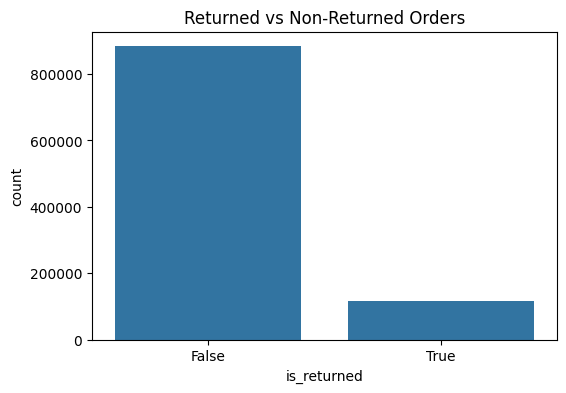

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_returned', data=df)

plt.title('Returned vs Non-Returned Orders')

plt.show()

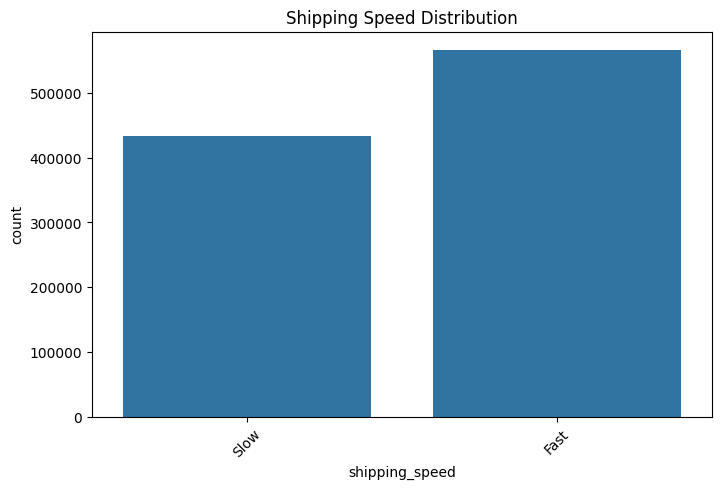

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='shipping_speed',
    data=df
)

plt.title('Shipping Speed Distribution')

plt.xticks(rotation=45)

plt.show()

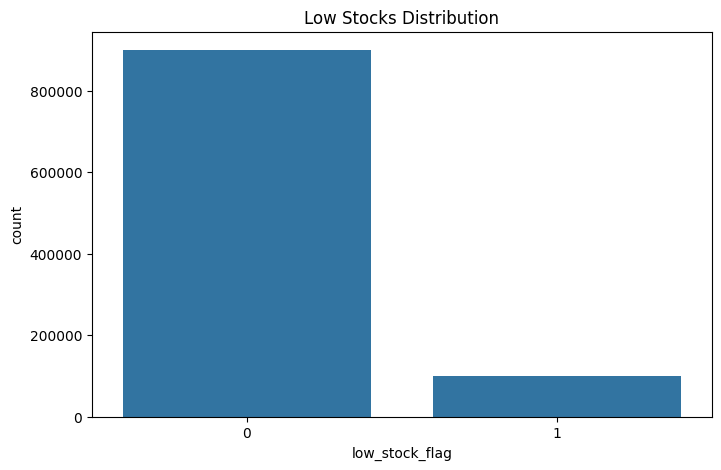

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='low_stock_flag',
    data=df
)

plt.title('Low Stocks Distribution')

plt.show()

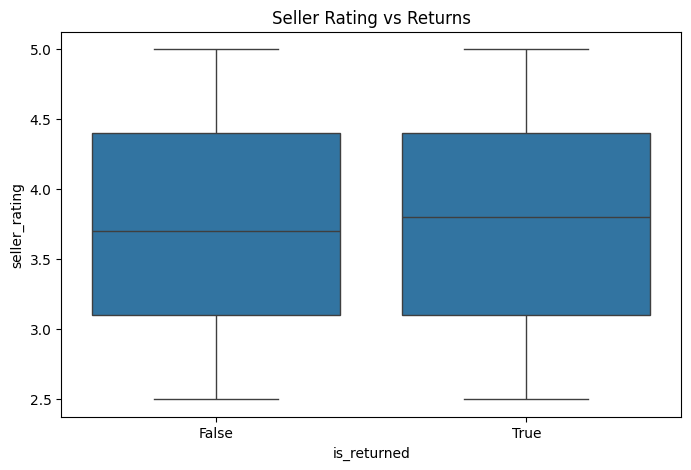

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_returned',
    y='seller_rating',
    data=df
)

plt.title('Seller Rating vs Returns')

plt.show()

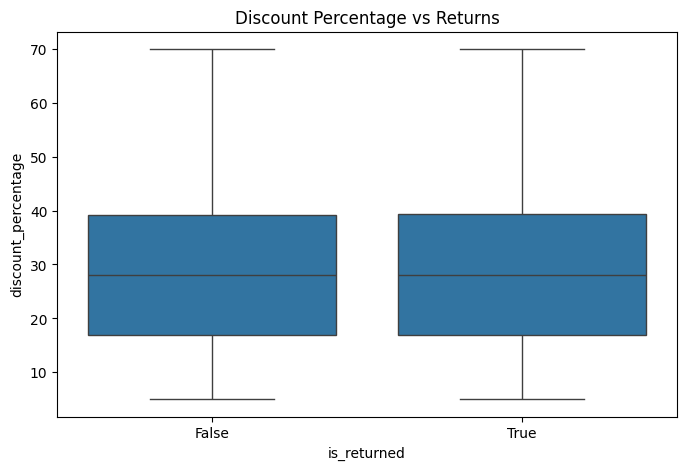

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_returned',
    y='discount_percentage',
    data=df
)

plt.title('Discount Percentage vs Returns')

plt.show()

**Correlation Matrices**

                            discount_percentage  seller_performance_encoded
discount_percentage                     1.00000                    -0.00062
seller_performance_encoded             -0.00062                     1.00000


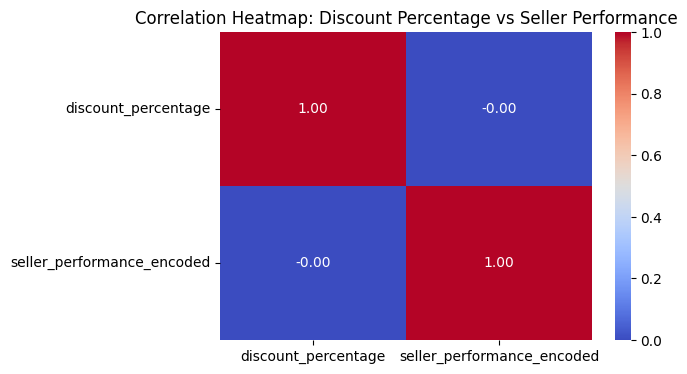

In [17]:
# ------------------------------------------
# Encode seller_performance if not encoded
# ------------------------------------------

le = LabelEncoder()

df['seller_performance_encoded'] = le.fit_transform(
    df['seller_performance']
)
# ------------------------------------------
# Select Features for Correlation
# ------------------------------------------
corr_features = df[[
    'discount_percentage',
    'seller_performance_encoded'
]]
# ------------------------------------------
# Compute Correlation Matrix
# ------------------------------------------

corr_matrix = corr_features.corr()

print(corr_matrix)
# ------------------------------------------
# Plot Heatmap
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap: Discount Percentage vs Seller Performance')

plt.show()


                     discount_percentage  popularity_score
discount_percentage             1.000000         -0.004266
popularity_score               -0.004266          1.000000


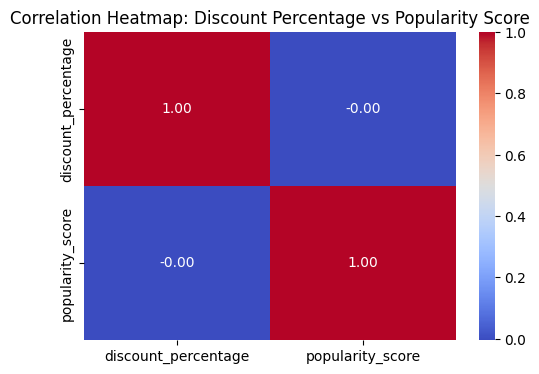

In [18]:
corr_features = df[[
    'discount_percentage',
    'popularity_score'
]]
# ------------------------------------------
# Compute Correlation Matrix
# ------------------------------------------

corr_matrix = corr_features.corr()
print(corr_matrix)
# ------------------------------------------
# Plot Heatmap
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap: Discount Percentage vs Popularity Score')

plt.show()


                            shipping_speed_encoded  seller_performance_encoded
shipping_speed_encoded                    1.000000                   -0.000923
seller_performance_encoded               -0.000923                    1.000000


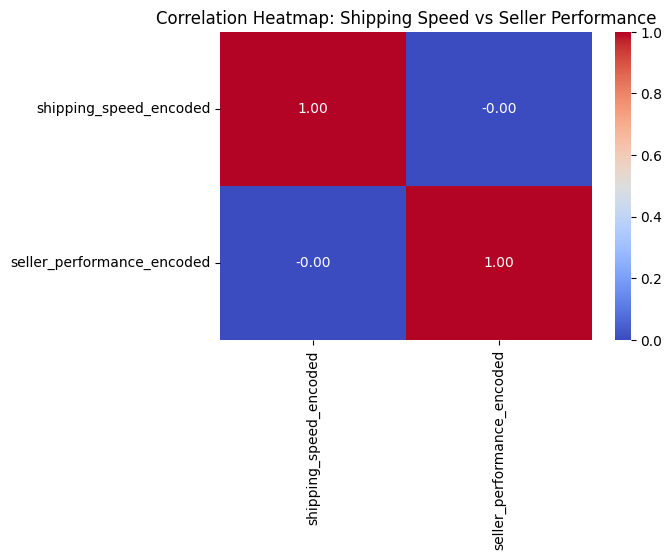

In [19]:
# ------------------------------------------
# Encode seller_performance if not encoded
# ------------------------------------------

le = LabelEncoder()

df['shipping_speed_encoded'] = le.fit_transform(
    df['shipping_speed']
)
le = LabelEncoder()

df['seller_performance_encoded'] = le.fit_transform(
    df['seller_performance']
)
corr_features = df[[
    'shipping_speed_encoded',
    'seller_performance_encoded'
]]
# ------------------------------------------
# Compute Correlation Matrix
# ------------------------------------------

corr_matrix = corr_features.corr()
print(corr_matrix)
# ------------------------------------------
# Plot Heatmap
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap: Shipping Speed vs Seller Performance')

plt.show()

                        shipping_speed_encoded  popularity_score
shipping_speed_encoded                1.000000          0.000302
popularity_score                      0.000302          1.000000


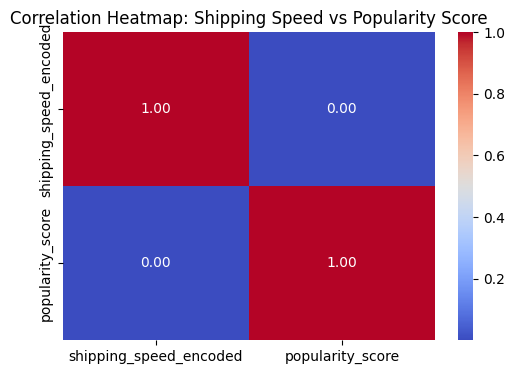

In [20]:
corr_features = df[[
    'shipping_speed_encoded',
    'popularity_score'
]]
# ------------------------------------------
# Compute Correlation Matrix
# ------------------------------------------

corr_matrix = corr_features.corr()
print(corr_matrix)
# ------------------------------------------
# Plot Heatmap
# ------------------------------------------

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap: Shipping Speed vs Popularity Score')

plt.show()

**Encode Target Variable**

In [21]:
df['is_returned'] = df['is_returned'].astype(int)

**Encode Categorical Variables**

In [22]:
categorical_cols = [
    'category',
    'subcategory',
    'brand',
    'location',
    'device',
    'payment_method',
    'delivery_status',
    'shipping_speed',
    'seller_performance'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

**Select Features for Model Training**

In [23]:
features = [
    'category',
    'subcategory',
    'brand',
    'price',
    'discount',
    'final_price',
    'rating',
    'review_count',
    'stock',
    'seller_rating',
    'shipping_time_days',
    'location',
    'device',
    'payment_method',
    'delivery_status',
    'discount_percentage',
    'popularity_score',
    'low_stock_flag',
    'purchase_month'
]

X = df[features]

y = df['is_returned']

**Train-Test Split**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Logistic Regression**

In [29]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.990535


**Random Forest**

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
1.0


**XGBoost Classifier**

In [27]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy:
1.0


**Compare Models for Best Prediction**

In [30]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
1,Random Forest,1.000000
2,XGBoost,1.000000
0,Logistic Regression,0.990535


In [31]:
# =========================================================
# 16. CLASSIFICATION REPORT
# =========================================================

print("\nXGBoost Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_xgb
))



XGBoost Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    176802
           1       1.00      1.00      1.00     23198

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



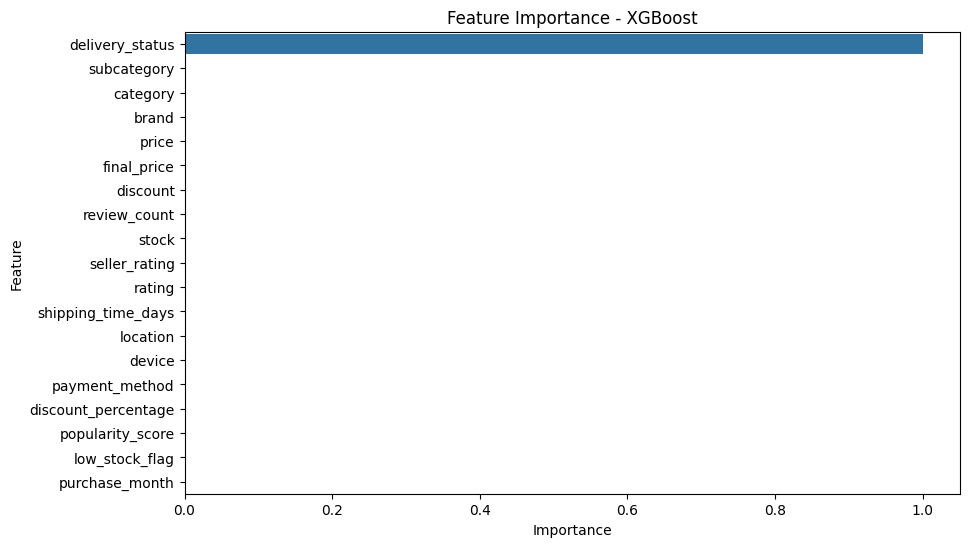

In [32]:
# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance - XGBoost')

plt.show()

In [33]:
corr = df.corr(numeric_only=True)

corr['is_returned'].sort_values(ascending=False)

is_returned                   1.000000
delivery_status               0.641026
shipping_time_days            0.052641
shipping_speed                0.035939
shipping_speed_encoded        0.035939
review_count                  0.001727
seller_rating                 0.001379
purchase_month                0.000888
discount                      0.000665
discount_percentage           0.000665
subcategory                   0.000524
brand                         0.000520
payment_method                0.000311
low_stock_flag                0.000053
stock                        -0.000730
device                       -0.000863
seller_performance_encoded   -0.001501
seller_performance           -0.001501
category                     -0.001641
popularity_score             -0.002634
final_price                  -0.006335
price                        -0.006719
location                     -0.012813
rating                       -0.043950
Name: is_returned, dtype: float64